Jupyter notebook to run through the getting started section of the icet Python library (https://icet.materialsmodeling.org/)

## Constructing the cluster expansion, Ag-Pd

In [1]:
from ase.db import connect
from icet import ClusterSpace, StructureContainer, ClusterExpansion
from trainstation import CrossValidationEstimator

In [2]:
db = connect('../data/reference_data.db')
primitive_structure = db.get(id=1).toatoms()  # primitive structure

To build the cluster expansion we first create a `ClusterSpace` from a prototype structure. This also requires cutoffs and the chemical elements allowed on each lattice site. The cutoffs set the maximum pairwise distance between atoms that can belong to the same cluster, given separately for each cluster order (pairs, triplets, quadruplets). Distances here are measured in Angstroms (Å), the standard length unit in atomistic modelling (1 Å = 10⁻¹⁰ m).

See https://icet.materialsmodeling.org/get_started/construct_cluster_expansion.html for more detail.

In [3]:
cs = ClusterSpace(structure=primitive_structure,
                  cutoffs=[13.5, 6.5, 6.0], # the cut-offs in question, 13.5 for pairs, 6.5 for triplets, 6 for quadruplets.
                  chemical_symbols=['Ag', 'Pd']) # the allowed elements
display(cs)

Field,Value
Space group,Fm-3m (225)
Sublattice A,"('Ag', 'Pd')"
Cutoffs,"[13.5, 6.5, 6.0]"
Total number of parameters,82
Number of parameters of order 0,1
Number of parameters of order 1,1
Number of parameters of order 2,25
Number of parameters of order 3,20
Number of parameters of order 4,35
fractional_position_tolerance,2e-06


Next we initialise a `StructureContainer`. We only attach one property (`mixing_energy`) here, but a container can hold several target properties per structure.

**`ClusterSpace` vs `StructureContainer`:**

```
ClusterSpace       = the basis. Given a prototype lattice, cutoffs, and allowed
                     elements, it enumerates all symmetrically distinct clusters
                     (pairs, triplets, ...). Defines *what* to measure, no data yet.

StructureContainer = the data. For each structure in the DB, projects it onto
                     the ClusterSpace basis -> feature vector, paired with target
                     property (e.g. mixing_energy).

Polynomial regression analogy:
  Choice of degree (e.g. up to x^3)   -> ClusterSpace (cutoffs + allowed elements)
  [1, x, x^2, x^3] for a given x      -> cluster vector (82 numbers here) for a crystal
  Design matrix X (stacked rows)      -> StructureContainer
  Coefficients c_i from least-squares -> ECIs from ClusterExpansion fit
  Final model: y ≈ sum(c_i * x^i)     -> energy ≈ X @ ECI
```

Cutoffs ↔ polynomial degree: both set how expressive the feature space is. Looser cutoffs / higher degree = more features, richer model, more overfit risk. It's a modelling choice about the basis, **not** a filter on the data.

The basis and data are kept separate because the basis is reusable: same `ClusterSpace`, swap datasets or add more target properties.

In [4]:
sc = StructureContainer(cluster_space=cs)
for row in db.select():
    sc.add_structure(structure=row.toatoms(),
                     user_tag=row.tag,
                     properties={'mixing_energy': row.mixing_energy})
display(sc)

,user_tag,natoms,formula,mixing_energy
0,Ag,1,Ag,0.000000
1,Pd,1,Pd,0.000000
2,AgPd_0002,2,AgPd,-0.039758
3,AgPd_0003,3,AgPd2,-0.028611
4,AgPd_0004,3,Ag2Pd,-0.048529
...,...,...,...,...
620,AgPd_0516,8,Ag4Pd4,-0.043282
621,AgPd_0517,8,Ag4Pd4,-0.040327
622,AgPd_0518,8,Ag4Pd4,-0.045361
623,AgPd_0519,8,Ag6Pd2,-0.046753


We can now fit the effective cluster interactions (ECIs) against the target mixing energies. We use cross-validation to choose a fit that generalises well beyond the training structures, then call `train` to produce the final coefficients.

In [5]:
opt = CrossValidationEstimator(
    fit_data=sc.get_fit_data(key='mixing_energy'), fit_method='ardr')
opt.validate()
opt.train()
print(opt)

============== CrossValidationEstimator ==============
seed                           : 42
fit_method                     : ardr
standardize                    : True
n_target_values                : 625
n_parameters                   : 82
n_nonzero_parameters           : 44
parameters_norm                : 0.07314093
target_values_std              : 0.01486413
rmse_train                     : 0.001632753
R2_train                       : 0.988
AIC                            : -7937.285
BIC                            : -7742.024
validation_method              : k-fold
n_splits                       : 10
rmse_train_final               : 0.001628285
rmse_validation                : 0.001889973
R2_validation                  : 0.9829637
shuffle                        : True


Roughly half of the 82 parameters are driven to zero. This is the effect of `ardr` (Automatic Relevance Determination Regression), a Bayesian sparse regression method that prunes unimportant features, somewhat similar to lasso, which keeps the model compact and helps generalisation.

Last step: attach the fitted parameters to the `ClusterSpace` to form a `ClusterExpansion`. On their own the parameters are just a vector of numbers. Pairing them with the cluster space is what lets us evaluate energies for new structures.

In [6]:
ce = ClusterExpansion(
    cluster_space=cs, parameters=opt.parameters, metadata=opt.summary)
display(ce)
ce.write('mixing_energy.ce')

Field,Value
Space group,Fm-3m (225)
Sublattice A,"('Ag', 'Pd')"
Cutoffs,"[13.5, 6.5, 6.0]"
Total number of parameters (nonzero),82 (44)
Number of parameters of order 0 (nonzero),1 (1)
Number of parameters of order 1 (nonzero),1 (1)
Number of parameters of order 2 (nonzero),25 (14)
Number of parameters of order 3 (nonzero),20 (13)
Number of parameters of order 4 (nonzero),35 (15)
fractional_position_tolerance,2e-06


## Analysing the Cluster Expansion

To gauge performance, we compare the cluster expansion's predicted mixing energies against the reference (DFT) mixing energies for the training structures.

In [7]:
ce = ClusterExpansion.read('mixing_energy.ce')
data = {'concentration': [], 'reference_energy': [], 'predicted_energy': []}
db = connect('../data/reference_data.db')
for row in db.select('natoms<=6'):
    data['concentration'].append(row.concentration)
    # the factor of 1e3 serves to convert from eV/atom to meV/atom
    data['reference_energy'].append(1e3 * row.mixing_energy)
    data['predicted_energy'].append(1e3 * ce.predict(row.toatoms()))

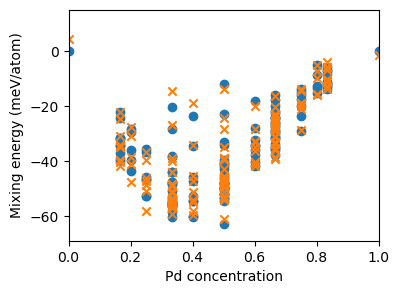

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 3))
ax.set_xlabel(r'Pd concentration')
ax.set_ylabel(r'Mixing energy (meV/atom)')
ax.set_xlim([0, 1])
ax.set_ylim([-69, 15])
ax.scatter(data['concentration'], data['reference_energy'],
           marker='o', label='reference')
ax.scatter(data['concentration'], data['predicted_energy'],
           marker='x', label='CE prediction')
plt.savefig('mixing_energy_comparison.png', bbox_inches='tight')

Predicted (orange crosses) and target (blue circles) mixing energies versus concentration for the structures used in the construction of the cluster expansion

Now we want to use our cluster expansion to predict mixing energies for a larger set of structures, which we obtain by enumeration.

In [9]:
import matplotlib.pyplot as plt
from numpy import array
from icet import ClusterExpansion
from icet.tools import ConvexHull, enumerate_structures

In [10]:
ce = ClusterExpansion.read('mixing_energy.ce')
species = ['Ag', 'Pd']
data = {'concentration': [], 'mixing_energy': []}
structures = []
cluster_space = ce.get_cluster_space_copy()
chemical_symbols = cluster_space.chemical_symbols
primitive_structure = cluster_space.primitive_structure
for structure in enumerate_structures(structure=primitive_structure,
                                      sizes=range(1, 13),
                                      chemical_symbols=chemical_symbols):
    conc = structure.symbols.count('Pd') / len(structure)
    data['concentration'].append(conc)
    data['mixing_energy'].append(ce.predict(structure))
    structures.append(structure)
print('Predicted energies for {} structures'.format(len(structures)))

Predicted energies for 10850 structures


Extract the convex hull of mixing energy vs. concentration, its vertices are the ground-state structures at each composition.

In [11]:
hull = ConvexHull(data['concentration'], data['mixing_energy'])

Now plot that

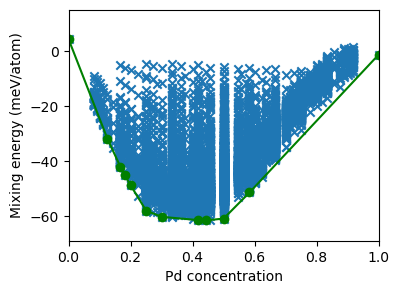

In [12]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.set_xlabel(r'Pd concentration')
ax.set_ylabel(r'Mixing energy (meV/atom)')
ax.set_xlim([0, 1])
ax.set_ylim([-69, 15])
ax.scatter(data['concentration'], 1e3 * array(data['mixing_energy']),
           marker='x')
ax.plot(hull.concentrations, 1e3 * hull.energies, '-o', color='green')
plt.savefig('mixing_energy_predicted.png', bbox_inches='tight')

Now filter for low energy configurations

In [13]:
tol = 0.0005
low_energy_structures = hull.extract_low_energy_structures(
    data['concentration'], data['mixing_energy'], tol)
print('Found {} structures within {} meV/atom of the convex hull'.
      format(len(low_energy_structures), 1e3 * tol))

Found 39 structures within 0.5 meV/atom of the convex hull


Now inspect how the ECIs vary with cluster radius and order. Physically meaningful fits tend to show interactions decaying with distance and with increasing order; if they don't, the cutoffs or fit method may need revisiting.

In [14]:
import numpy as np

ce = ClusterExpansion.read('mixing_energy.ce')
df_ecis = ce.to_dataframe()

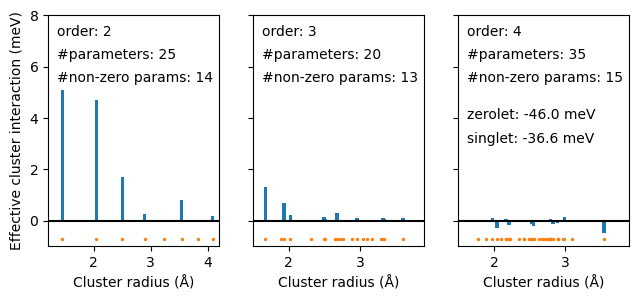

In [15]:
fig, axs = plt.subplots(1, 3, sharey=True, figsize=(7.5, 3))
for k, order in enumerate(ce.orders):
    df_order = df_ecis.loc[df_ecis['order'] == order]
    if k < 2 or k > 4:
        continue
    ax = axs[k - 2]
    ax.set_ylim((-1, 8))
    ax.set_xlabel(r'Cluster radius (Å)')
    if order == 2:
        ax.set_xlim((1.2, 4.2))
        ax.set_ylabel(r'Effective cluster interaction (meV)')
    if order == 3:
        ax.set_xlim((1.5, 3.9))
    if order == 4:
        ax.set_xlim((1.5, 3.9))
        ax.text(0.05, 0.55, 'zerolet: {:.1f} meV'
                .format(1e3 * df_ecis.eci.iloc[0]),
                transform=ax.transAxes)
        ax.text(0.05, 0.45, 'singlet: {:.1f} meV'
                .format(1e3 * df_ecis.eci.iloc[1]),
                transform=ax.transAxes)
    ax.plot([0, 5], [0, 0], color='black')
    ax.bar(df_order.radius, 1e3 * df_order.eci, width=0.05)
    ax.scatter(df_order.radius, len(df_order) * [-0.7],
               marker='o', s=2.0)
    ax.text(0.05, 0.91, 'order: {}'.format(order),
            transform=ax.transAxes)
    ax.text(0.05, 0.81, '#parameters: {}'.format(len(df_order)),
            transform=ax.transAxes,)
    ax.text(0.05, 0.71, '#non-zero params: {}'
            .format(np.count_nonzero(df_order.eci)),
            transform=ax.transAxes,)
plt.savefig('ecis.png', bbox_inches='tight')

## Sampling the Cluster Expansion

Now we have our cluster expansion, we can use the built-in MCMC sampler to draw configurations from it.

In [16]:
from ase.build import make_supercell
from icet import ClusterExpansion
from mchammer.calculators import ClusterExpansionCalculator
from mchammer.ensembles import SemiGrandCanonicalEnsemble, VCSGCEnsemble
import numpy as np
from os import mkdir

**Supercell.** A crystal's *primitive cell* is the smallest repeating unit that tiles the lattice under periodic boundary conditions — for FCC Ag that's a single atom. A *supercell* is a larger box built by tiling the primitive cell (here 108 atoms), which becomes the MC simulation box. We need this because MC samples configurations by swapping species across many sites — one atom has nothing to flip, and finite-size effects shrink as the box grows.

The `ClusterExpansionCalculator` wraps the CE + supercell so the MC ensembles can evaluate energies on it. The self-interaction warning appears because the 13.5 Å pair cutoff exceeds half the supercell edge (clusters wrap onto their own periodic image) — tolerable for a tutorial, but production runs want a larger cell.

In [17]:
ce = ClusterExpansion.read('mixing_energy.ce')
structure = make_supercell(ce.get_cluster_space_copy().primitive_structure,
                           3 * np.array([[-1, 1, 1],
                                         [1, -1, 1],
                                         [1, 1, -1]]))
calculator = ClusterExpansionCalculator(structure, ce)

icet: WARNING  The ClusterExpansionCalculator self-interacts, which may lead to erroneous results. To avoid self-interaction, use a larger supercell or a cluster space with shorter cutoffs.


**Semi-Grand Canonical (SGC) ensemble.** Atom count is fixed but composition fluctuates: each trial step flips a site's species and accepts/rejects based on energy change plus a chemical-potential penalty Δμ = μ_Pd − μ_Ag. Sweeping Δμ at fixed T traces out composition vs. chemical potential, which is the thermodynamic response we want for phase behaviour. We run at T = 900 K (expected disordered) and T = 300 K (expected ordered) to see how ordering changes with temperature.

In [18]:
# Make sure output directory exists
output_directory = 'monte_carlo_data'
try:
    mkdir(output_directory)
except FileExistsError:
    pass
for temperature in [900, 300]:
    # Evolve configuration through the entire composition range
    for dmu in np.arange(-0.7, 0.51, 0.05):
        # Initialize MC ensemble
        fname = f'{output_directory}/sgc-T{temperature}-dmu{dmu:+.3f}.dc'
        mc = SemiGrandCanonicalEnsemble(
            structure=structure,
            calculator=calculator,
            temperature=temperature,
            dc_filename=fname,
            chemical_potentials={'Ag': 0, 'Pd': dmu})

        mc.run(number_of_trial_steps=len(structure) * 30)
        structure = mc.structure

**Variance-Constrained SGC (VCSGC).** Same spirit as SGC, but swaps the linear Δμ term for a *quadratic* constraint that softly pins the average concentration near a target value (controlled by `phi` ∈ roughly [−2, 0]) with strength `kappa`. This fixes SGC's main weakness: inside two-phase regions SGC jumps discontinuously between compositions, so you can't sample intermediate concentrations. VCSGC can, which makes it the better tool for mapping miscibility gaps and ordering transitions.

In [19]:
# Make sure output directory exists
output_directory = 'monte_carlo_data'
try:
    mkdir(output_directory)
except FileExistsError:
    pass
for temperature in [900, 300]:
    # Evolve configuration through the entire composition range
    for phi in np.arange(-2.1, 0.11, 0.08):
        # Initialize MC ensemble
        fname = f'{output_directory}/vcsgc-T{temperature}-phi{phi:+.3f}.dc'
        mc = VCSGCEnsemble(
            structure=structure,
            calculator=calculator,
            temperature=temperature,
            dc_filename=fname,
            phis={'Pd': phi},
            kappa=200)

        mc.run(number_of_trial_steps=len(structure) * 30)
        structure = mc.structure

We now want to analyse our simulations.

In [20]:
import pandas as pd
from glob import glob
from mchammer import DataContainer

Collect data from simulations and write to csv format.

In [21]:
for ensemble in ['sgc', 'vcsgc']:
    data = []
    for filename in glob('monte_carlo_data/{}-*.dc'.format(ensemble)):
        dc = DataContainer.read(filename)
        data_row = dc.ensemble_parameters
        data_row['filename'] = filename
        n_atoms = data_row['n_atoms']

        equilibration = 5 * n_atoms

        stats = dc.analyze_data('Pd_count', start=equilibration)
        data_row['Pd_concentration'] = stats['mean'] / n_atoms
        data_row['Pd_concentration_error'] = stats['error_estimate'] / n_atoms

        stats = dc.analyze_data('potential', start=equilibration)
        data_row['mixing_energy'] = stats['mean'] / n_atoms
        data_row['mixing_energy_error'] = stats['error_estimate'] / n_atoms

        data_row['acceptance_ratio'] = \
            dc.get_average('acceptance_ratio', start=equilibration)
        if ensemble == 'sgc':
            data_row['free_energy_derivative'] = \
                dc.ensemble_parameters['mu_Pd'] - \
                dc.ensemble_parameters['mu_Ag']
        elif ensemble == 'vcsgc':
            data_row['free_energy_derivative'] = \
                dc.get_average('free_energy_derivative_Pd', start=equilibration)

        data.append(data_row)
    
    df = pd.DataFrame(data)
    df.to_csv('monte-carlo-{}.csv'.format(ensemble), sep='\t')

/Users/mitchcrabb/Documents/Imperial/Modules/Dissertation/msc-dissertation-dnfs/.pixi/envs/default/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mitchcrabb/Documents/Imperial/Modules/Dissertation/msc-dissertation-dnfs/.pixi/envs/default/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/mitchcrabb/Documents/Imperial/Modules/Dissertation/msc-dissertation-dnfs/.pixi/envs/default/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mitchcrabb/Documents/Imperial/Modules/Dissertation/msc-dissertation-dnfs/.pixi/envs/default/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/mitchcrabb/Documents/Impe

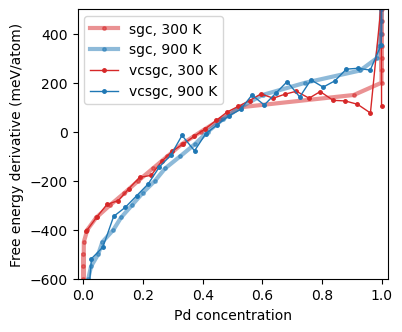

In [22]:
dfs = {}
dfs['sgc'] = pd.read_csv('monte-carlo-sgc.csv', delimiter='\t')
dfs['vcsgc'] = pd.read_csv('monte-carlo-vcsgc.csv', delimiter='\t')


# step 1: Plot free energy derivatives
colors = {300: '#D62728',
          900: '#1F77B4'}
linewidths = {'sgc': 3, 'vcsgc': 1}
alphas = {'sgc': 0.5, 'vcsgc': 1.0}
fig, ax = plt.subplots(figsize=(4, 3.5))
for ensemble, df in dfs.items():
    for T in sorted(df.temperature.unique()):
        df_T = df.loc[df['temperature'] == T].sort_values('Pd_concentration')
        ax.plot(df_T['Pd_concentration'],
                1e3 * df_T['free_energy_derivative'],
                marker='o', markersize=2.5,
                label='{}, {} K'.format(ensemble, T),
                color=colors[T],
                linewidth=linewidths[ensemble], alpha=alphas[ensemble])
ax.set_xlabel('Pd concentration')
ax.set_ylabel('Free energy derivative (meV/atom)')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-600, 500])
ax.legend()
plt.savefig('free_energy_derivative.png', bbox_inches='tight')

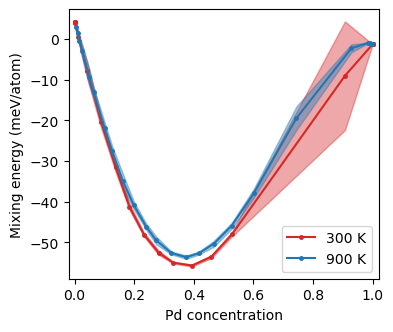

In [23]:
df = dfs['sgc']
fig, ax = plt.subplots(figsize=(4, 3.5))
for T in sorted(df.temperature.unique()):
    df_T = df.loc[df['temperature'] == T].sort_values('Pd_concentration')
    e_mix = 1e3 * df_T['mixing_energy']
    e_mix_error = 1e3 * df_T['mixing_energy_error']
    ax.plot(df_T['Pd_concentration'], e_mix,
            marker='o', markersize=2.5, label='{} K'.format(T),
            color=colors[T])
    # Plot error estimate
    ax.fill_between(df_T['Pd_concentration'],
                    e_mix + e_mix_error, e_mix - e_mix_error,
                    color=colors[T], alpha=0.4)
ax.set_xlabel('Pd concentration')
ax.set_ylabel('Mixing energy (meV/atom)')
ax.set_xlim([-0.02, 1.02])
ax.legend()
plt.savefig('mixing_energy_sgc.png', bbox_inches='tight')

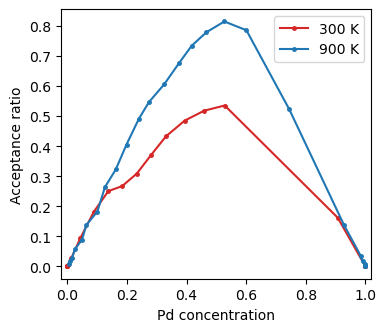

In [24]:
df = dfs['sgc']
fig, ax = plt.subplots(figsize=(4, 3.5))
for T in sorted(df.temperature.unique()):
    df_T = df.loc[df['temperature'] == T].sort_values('Pd_concentration')
    ax.plot(df_T['Pd_concentration'], df_T['acceptance_ratio'],
            marker='o', markersize=2.5, label='{} K'.format(T),
            color=colors[T])
ax.set_xlabel('Pd concentration')
ax.set_ylabel('Acceptance ratio')
ax.set_xlim([-0.02, 1.02])
ax.legend()
plt.savefig('acceptance_ratio_sgc.png', bbox_inches='tight')